<a href="https://colab.research.google.com/github/ShiftorTheOrca/asah-capstone/blob/nevets/ples_send_help.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**

In [110]:
# Library Essential
import numpy as np
import pandas as pd
import os
import shutil
from google.colab import files
from datetime import datetime

# Library Pre-processing Data
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA

# Library Machine Learning
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Library Visualisasi Data
import plotly as py
import plotly.graph_objs as go
import seaborn as sns
import matplotlib.pyplot as plt


# **Load Dataset**

Load dataset yang dari Kaggle:
- Online Retail Dataset (UCI)
- Online Retail Dataset II (UCI)

In [111]:
# Upload file .json untuk API key
files.upload()
print("API Key Received")

API Key Received


In [112]:
os.makedirs('/root/.kaggle', exist_ok=True)

# Download dataset dari Kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d viridianachow/online-retail-uci-dataset
!kaggle datasets download -d mashlyn/online-retail-ii-uci

Dataset URL: https://www.kaggle.com/datasets/viridianachow/online-retail-uci-dataset
License(s): unknown
online-retail-uci-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
License(s): CC0-1.0
online-retail-ii-uci.zip: Skipping, found more recently modified local copy (use --force to force download)


In [113]:
!unzip "online-retail-uci-dataset.zip"
!unzip "online-retail-ii-uci.zip"

Archive:  online-retail-uci-dataset.zip
replace Online Retail.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
Archive:  online-retail-ii-uci.zip
replace online_retail_II.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [114]:
# Simpan dataset dari csv ke DataFrame Pandas
df_1 = pd.read_csv('Online Retail.csv')
df_2 = pd.read_csv('online_retail_II.csv')

In [115]:
df_1.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom


In [116]:
df_2.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


# **Exploratory Data Analysis**

Exploratory Data Analysis (EDA) untuk mencari dari pola data pembelian

In [117]:
# # Menyamakan nama kolom agar kedua DataFrame dapat digabung
column_names = ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']
df_1.columns = df_2.columns = column_names

In [118]:
# Gabung menjadi 1 DataFrame
# df_all = pd.concat([df_1, df_2])
df_all = df_1
df_all.head(-1)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541903,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,12/9/11 12:50,4.15,12680.0,France
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/11 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/11 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/11 12:50,4.15,12680.0,France


### Informasi Dataset

In [119]:
# Tampilkan info dataset
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   Price        541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [120]:

df_all.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/11 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


In [121]:
print(f'quantity unique: {df_all['Quantity'].nunique()}')
print(f'price unique: {df_all['Price'].nunique()}')
print(f'CustomerID unique: {df_all['CustomerID'].nunique()}')

quantity unique: 722
price unique: 1630
CustomerID unique: 4372


In [122]:
df_all['Invoice'].isna().sum()

np.int64(0)

### Korelasi Antar Variabel

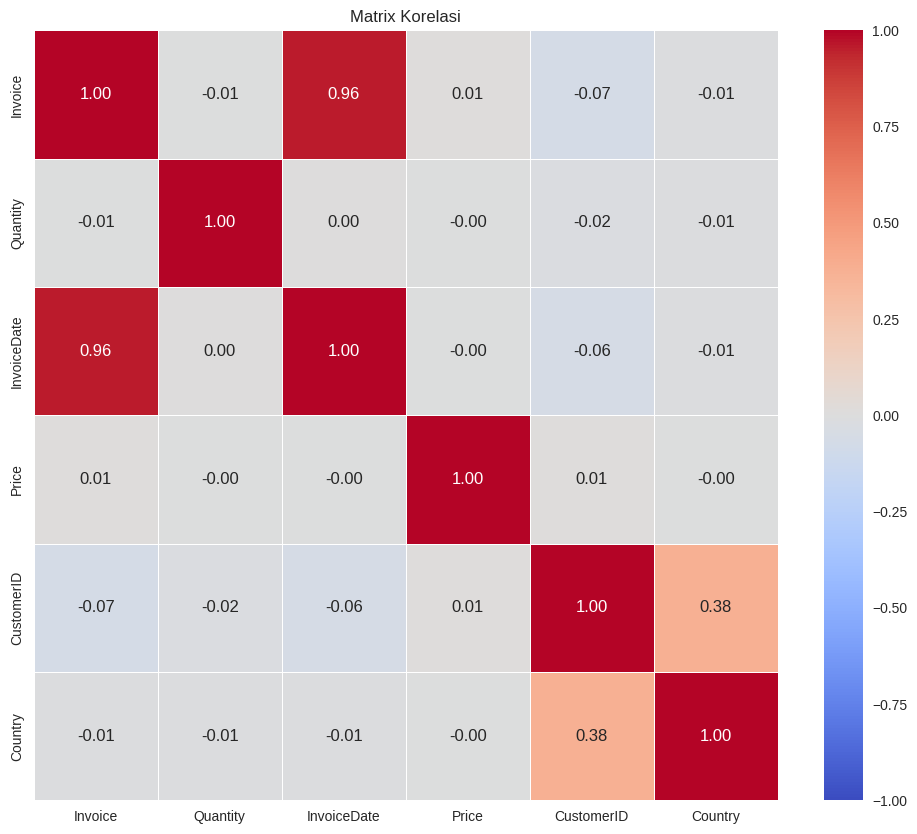

In [123]:
# Encode variabel kategorikal yang relevan
label_encoder = LabelEncoder()
df_lencoder = df_all.drop(['StockCode', 'Description'], axis=1)

# Konversi tanggal ke format yang sesuai
df_lencoder['InvoiceDate'] = pd.to_datetime(df_lencoder['InvoiceDate'], format='mixed')
category_features = ['Invoice', 'CustomerID', 'Country']
for col in category_features:
  df_lencoder[col] = label_encoder.fit_transform(df_all[col])

plt.figure(figsize=(12, 10))
matrix_korelasi = df_lencoder.corr()

sns.heatmap(matrix_korelasi, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matrix Korelasi')
plt.show()

Text(0.5, 1.0, 'Histogram Sebelum Standardisasi')

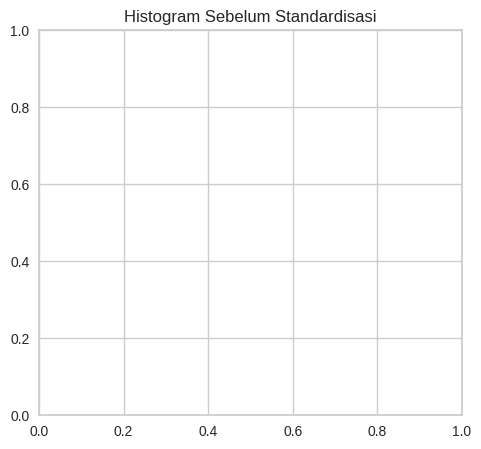

In [124]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
df_1['Price']
plt.title("Histogram Sebelum Standardisasi")

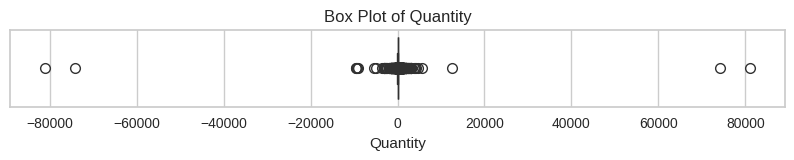

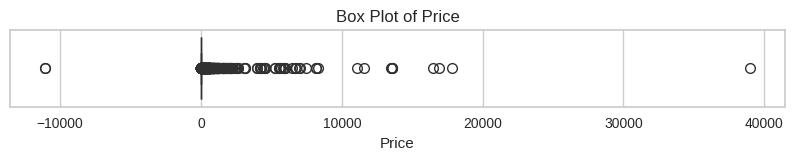

In [125]:
numerik = ['Quantity', 'Price']
for feature in numerik:
  plt.figure(figsize=(10, 1))
  sns.boxplot(x=df_all[feature])
  plt.title(f'Box Plot of {feature}')
  plt.show()

# **Data Cleaning & Preprocessing**

### Data Cleaning

##### Hapus missing values dan data duplikat

In [126]:
print("Data duplikat:", df_all.duplicated().sum())

print("Data hilang: ")
missing_values = df_all.isnull().sum()
missing_values[missing_values > 0]

Data duplikat: 5268
Data hilang: 


,0
Description,1454
CustomerID,135080


In [127]:
# Hapus data duplikat
df_clean = df_all.drop_duplicates()

# Hapus data hilang
filter_custID = (df_clean['CustomerID'].notnull() & df_clean['Description'].notnull())
df_clean = df_clean[filter_custID]

In [128]:
# Cek informasi dataset setelah cleaning
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      401604 non-null  object 
 1   StockCode    401604 non-null  object 
 2   Description  401604 non-null  object 
 3   Quantity     401604 non-null  int64  
 4   InvoiceDate  401604 non-null  object 
 5   Price        401604 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      401604 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.6+ MB


##### Hapus data negatif

In [129]:
# Buat & apply filter untuk data negatif
filter_price = df_clean['Price'] >= 0
df_clean = df_clean[filter_price]
filter_quantity = df_clean['Quantity'] >= 0
df_clean = df_clean[filter_quantity]

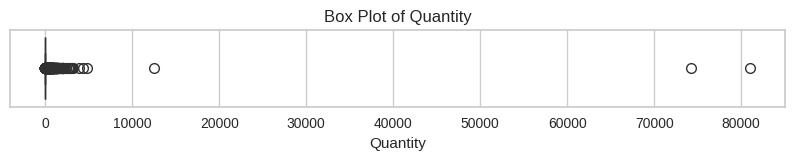

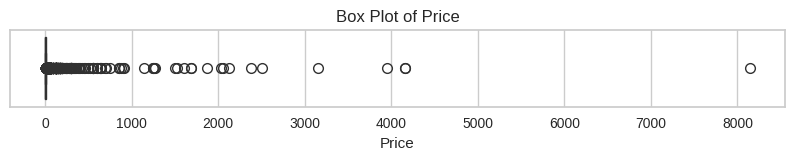

In [130]:
column_display = ['Quantity', 'Price']
for feature in column_display:
  plt.figure(figsize=(10, 1))
  sns.boxplot(x=df_clean[feature])
  plt.title(f'Box Plot of {feature}')
  plt.show()

In [131]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      392732 non-null  object 
 1   StockCode    392732 non-null  object 
 2   Description  392732 non-null  object 
 3   Quantity     392732 non-null  int64  
 4   InvoiceDate  392732 non-null  object 
 5   Price        392732 non-null  float64
 6   CustomerID   392732 non-null  float64
 7   Country      392732 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.0+ MB


##### Hapus Outlier

In [132]:
# Data numerik outlier dicari dan dibuang\n",
# Pemilihan field dilakukan manual karena CustomerID tidak termasuk numerik;\n",
# namun pada DataFrame dikategorikan sebagai numerik (float64)\n",
numerik = ['Quantity', 'Price']
print("Sebelum drop outlier:", df_clean.shape)
for col in numerik:
  # Cari kuantil 1 dan 3 setiap untuk mendapatkan batas bawah & batas atas\n",
  Q1 = df_clean[col].quantile(0.25)
  Q3 = df_clean[col].quantile(0.75)
  IQR = Q3 - Q1
  batas_bawah = Q1 - 1.5 * IQR
  batas_atas = Q3 + 1.5 * IQR
  # Outlier = data yang di nilainya di bawah batas bawah/di atas batas atas\n",
  outlier = df_clean[(df_clean[col] < batas_bawah) | (df_clean[col] > batas_atas)]

  print()
  print("Kolom", col, "memiliki batas bawah", batas_bawah, "dan batas atas", batas_atas)

  df_clean = df_clean.drop(outlier.index)
  print("Setelah drop outlier", col, ":", df_clean.shape)

Sebelum drop outlier: (392732, 8)

Kolom Quantity memiliki batas bawah -13.0 dan batas atas 27.0
Setelah drop outlier Quantity : (367107, 8)

Kolom Price memiliki batas bawah -2.5 dan batas atas 7.5
Setelah drop outlier Price : (333265, 8)


In [133]:
df_clean.describe()

,Quantity,Price,CustomerID
count,333265.000000,333265.000000,333265.000000
mean,7.550568,2.194014,15318.810544
std,6.777327,1.546087,1711.210934
min,1.000000,0.000000,12347.000000
25%,2.000000,1.250000,13988.000000
50%,6.000000,1.650000,15235.000000
75%,12.000000,2.950000,16814.000000
max,27.000000,7.500000,18287.000000


### Preprocessing Data

In [134]:
# Konversi format tanggal agar terstandarisasi
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], format='mixed')

# Ubah CustomerID menjadi integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [135]:
df_clean = df_clean.sort_values('InvoiceDate')
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541896,581587,22555,PLASTERS IN TIN STRONGMAN,12,2011-12-09 12:50:00,1.65,12680,France
541895,581587,22556,PLASTERS IN TIN CIRCUS PARADE,12,2011-12-09 12:50:00,1.65,12680,France
541894,581587,22631,CIRCUS PARADE LUNCH BOX,12,2011-12-09 12:50:00,1.95,12680,France
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,12680,France


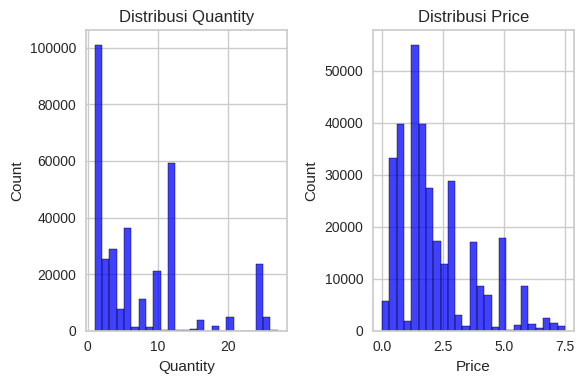

In [136]:
column_display = ['Quantity', 'Price']
plt.figure(figsize=(6, 4))

for i, column in enumerate(column_display, 1):
  plt.subplot(1, 2, i)
  sns.histplot(df_clean[column], bins=25, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

# **Persiapan RFM**

Recency: Kapan terakhir seorang user melakukan transaksi

Frequency: Seberapa sering user melakukan transaksi

Monetary: Seberapa besar transaksi yang dilakukan user

### Pembuatan Variabel untuk RFM

In [137]:
# Hitung total belanja setiap barang
df_clean['Total'] = df_clean['Quantity'] * df_clean['Price']
df_clean.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00


In [138]:
# Asumsi data diambil pada saat entri data terakhir
tgl_pengambilan = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Mengelompokkan data berdasarkan customer dan buat kolom baru untuk R, F, dan M
df_rfm = df_clean.groupby('CustomerID').agg(
  Recency=('InvoiceDate', lambda x: (tgl_pengambilan - x.max()).days),
  Frequency=('Invoice', 'nunique'),
  Monetary=('Total', 'sum')
).reset_index()
df_rfm

,CustomerID,Recency,Frequency,Monetary
0,12347,2,7,3314.73
1,12348,249,3,90.20
2,12349,19,1,999.15
3,12350,310,1,294.40
4,12352,36,7,1130.94
...,...,...,...,...
4187,18280,278,1,137.00
4188,18281,181,1,46.92
4189,18282,8,2,113.13
4190,18283,4,16,2002.63


In [139]:
df_rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4192.000000,4192.000000,4192.000000,4192.000000
mean,15290.259065,92.458492,4.015983,1025.638403
std,1719.353408,99.897044,7.022919,2199.980606
min,12347.000000,1.000000,1.000000,0.000000
25%,13808.750000,18.000000,1.000000,206.120000
50%,15280.500000,51.000000,2.000000,465.770000
75%,16770.250000,143.000000,4.000000,1126.985000
max,18287.000000,374.000000,197.000000,84980.890000


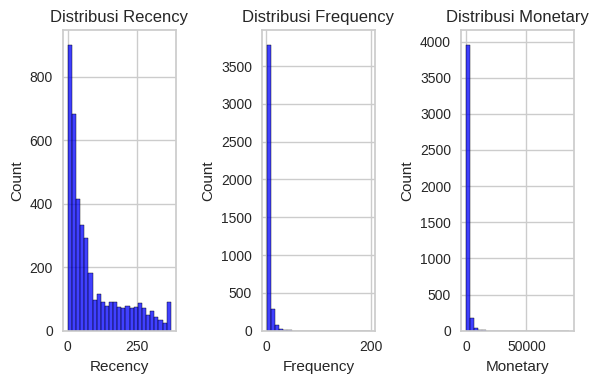

In [140]:
column = ['Recency', 'Frequency', 'Monetary']
plt.figure(figsize=(6, 4))

for i, column in enumerate(column, 1):
  plt.subplot(1, 3, i)
  sns.histplot(df_rfm[column], bins=25, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

### Transformasi agar data lebih balanced

In [141]:
# Transformasi logaritmik
df_rfm_log = df_rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p, axis=1)
df_rfm_log.head()

,Recency,Frequency,Monetary
0,1.098612,2.079442,8.106433
1,5.521461,1.386294,4.513055
2,2.995732,0.693147,6.907905
3,5.739793,0.693147,5.688330
4,3.610918,2.079442,7.031688


In [155]:
# Standarisasi data
scaler = MinMaxScaler()
rfm_minmax = scaler.fit_transform(df_rfm_log)


df_rfm_minmax = pd.DataFrame(rfm_minmax, columns=['Recency', 'Frequency', 'Monetary'])
df_rfm_minmax.head()

,Recency,Frequency,Monetary
0,0.077471,0.301688,0.714211
1,0.922529,0.150844,0.397619
2,0.439947,0.000000,0.608616
3,0.964245,0.000000,0.501166
4,0.557488,0.301688,0.619521


In [181]:
columns = ['Recency', 'Frequency', 'Monetary']
for cols in columns:
  bins = [0, 0.2, 0.4, 0.6, 0.8, 1.01]
  labels = [1, 2, 3, 4, 5]
  featureName = "bin" + cols
  df_rfm_minmax[featureName] = pd.cut(df_rfm_minmax[cols], bins=bins, labels=labels,right=False)
  df_rfm_minmax[featureName] = df_rfm_minmax[featureName].astype(int)
df_rfm_minmax.head(-1)

,Recency,Frequency,Monetary,binRecency,binFrequency,binMonetary
0,0.077471,0.301688,0.714211,1,2,4
1,0.922529,0.150844,0.397619,5,1,2
2,0.439947,0.000000,0.608616,3,1,4
3,0.964245,0.000000,0.501166,5,1,3
4,0.557488,0.301688,0.619521,3,2,4
...,...,...,...,...,...,...
4186,0.692490,0.000000,0.454989,4,1,3
4187,0.943499,0.000000,0.434112,5,1,3
4188,0.861874,0.000000,0.340922,5,1,2
4189,0.287379,0.088238,0.417380,2,1,3


In [182]:
df_rfm_minmax.isna().sum()

,0
Recency,0
Frequency,0
Monetary,0
binRecency,0
binFrequency,0
binMonetary,0


In [183]:
df_rfm_minmax.describe()

,Recency,Frequency,Monetary,binRecency,binFrequency,binMonetary
count,4192.000000,4192.000000,4192.000000,4192.000000,4192.000000,4192.000000
mean,0.600062,0.136444,0.543274,3.490219,1.309399,3.225668
std,0.255002,0.143904,0.110169,1.247627,0.602965,0.610205
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.430147,0.000000,0.469886,3.000000,1.000000,3.000000
50%,0.622513,0.088238,0.541474,4.000000,1.000000,3.000000
75%,0.817128,0.199405,0.619213,5.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000


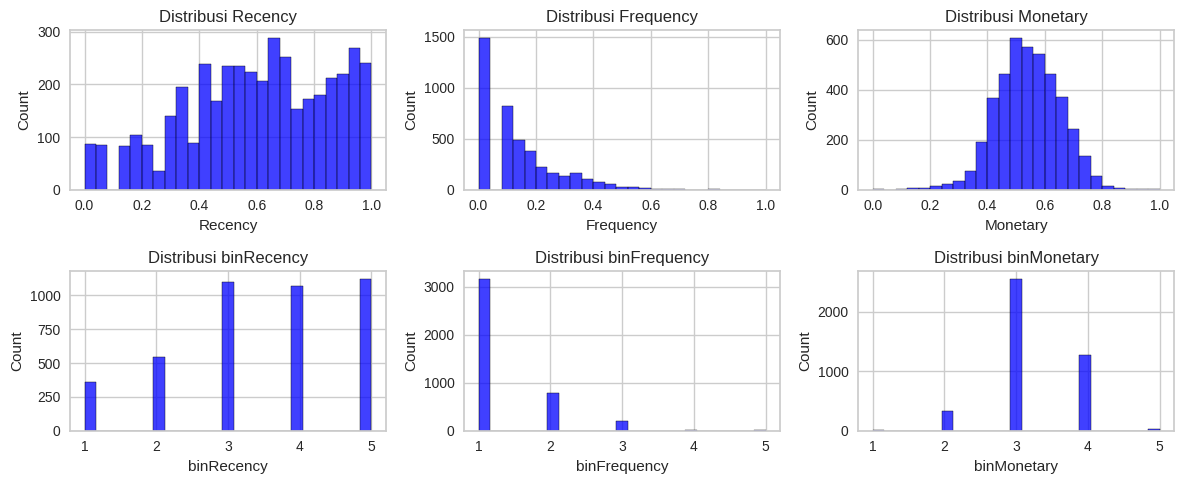

In [184]:
column = ['Recency', 'Frequency', 'Monetary', 'binRecency', 'binFrequency', 'binMonetary']
plt.figure(figsize=(12,5))
i = 0
for i, column in enumerate(column, i+1):
  plt.subplot(2, 3, i)
  sns.histplot(df_rfm_minmax[column], bins=25, color='blue')
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

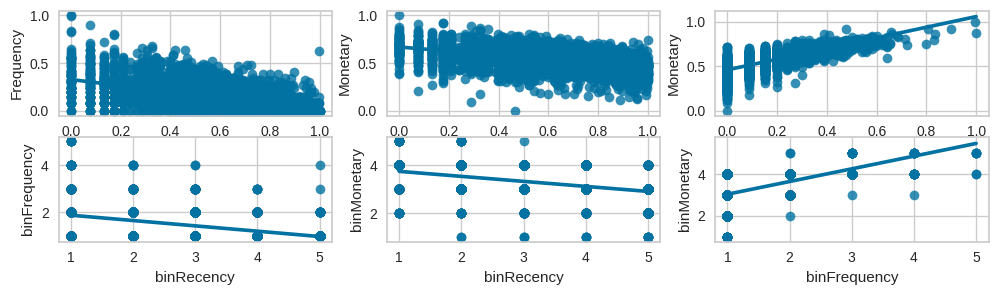

In [185]:
plt.figure(1, figsize=(12, 3))

plt.subplot(2 , 3 , 1)
sns.regplot(x='Recency' , y='Frequency' , data=df_rfm_minmax)

plt.subplot(2 , 3 , 2)
sns.regplot(x='Recency' , y='Monetary' , data=df_rfm_minmax)

plt.subplot(2 , 3 , 3)
sns.regplot(x='Frequency' , y='Monetary' , data=df_rfm_minmax)
plt.subplot(2 , 3 , 4)
sns.regplot(x='binRecency' , y='binFrequency' , data=df_rfm_minmax)

plt.subplot(2 , 3 , 5)
sns.regplot(x='binRecency' , y='binMonetary' , data=df_rfm_minmax)

plt.subplot(2 , 3 , 6)
sns.regplot(x='binFrequency' , y='binMonetary' , data=df_rfm_minmax)

plt.show()

# **Clustering**

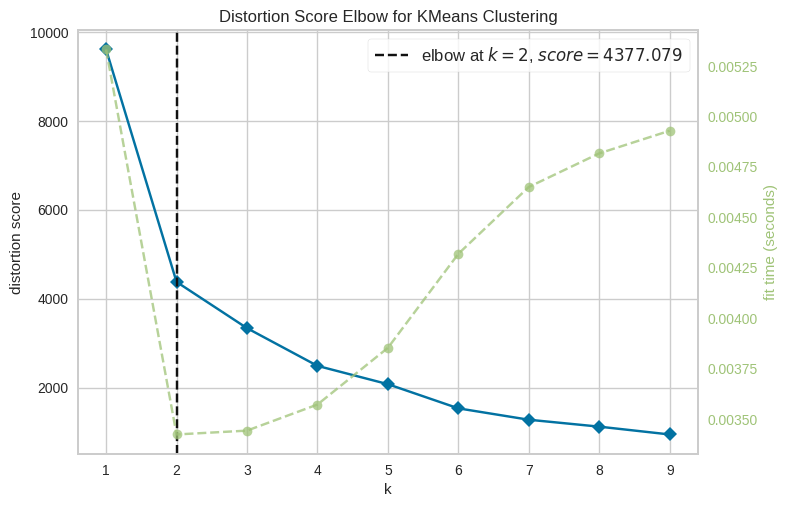

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [186]:
kmeans_elbow = KMeans()
visualizer = KElbowVisualizer(kmeans_elbow, k=(1, 10))
visualizer.fit(df_rfm_minmax[['binRecency','binFrequency','binMonetary']])
visualizer.show()

### K-Means

In [191]:
k_elbow = 4
kmeans = KMeans(n_clusters=k_elbow)
kmeans.fit(df_rfm_minmax[['binRecency','binFrequency','binMonetary']])
labels = kmeans.labels_

# Catat label (cluster) setiap data
df_rfm['Cluster'] = labels
df_rfm_minmax['Cluster'] = labels

In [192]:
# Analisis karakter cluster
cluster_analysis = df_rfm.groupby('Cluster').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count'),
    Percentage=('CustomerID', lambda x: (x.count() / len(df_rfm_minmax)) * 100)
).sort_values(by='Avg_Recency', ascending=False)

cluster_analysis


,Avg_Recency,Avg_Frequency,Avg_Monetary,Count,Percentage
Cluster,,,,,
1,239.034728,1.579697,325.202165,1123,26.789122
3,76.775701,2.647664,692.003684,1070,25.524809
0,22.037607,2.453846,569.478103,1170,27.910305
2,13.529554,11.287093,3048.903293,829,19.775763


In [193]:
ss_k = silhouette_score(df_rfm, df_rfm['Cluster'])
print("Silhouette Score K-Means =", ss_k)

ss_k_minmax = silhouette_score(df_rfm_minmax, df_rfm['Cluster'])
print("Silhouette Score K-Means (MinMax) =", ss_k_minmax)

Silhouette Score K-Means = -0.026150492149483937
Silhouette Score K-Means (MinMax) = 0.6561064160812022


In [194]:
visual_3d = go.Scatter3d(
  x= df_rfm_minmax['Recency'],
  y= df_rfm_minmax['Frequency'],
  z= df_rfm_minmax['Monetary'],
  mode='markers',
    marker=dict(
      color = df_rfm_minmax['Cluster'],
      size= 20,
      line=dict(
        color= df_rfm_minmax['Cluster'],
        width= 12
      ),
      opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
  title= 'Clusters',
  scene = dict(
    xaxis = dict(title  = 'Recency'),
    yaxis = dict(title  = 'Frequency'),
    zaxis = dict(title  = 'Monetary')
  )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

In [ ]:
visual_3d = go.Scatter3d(
  x= df_rfm['Recency'],
  y= df_rfm['Frequency'],
  z= df_rfm['Monetary'],
  mode='markers',
    marker=dict(
      color = df_rfm['Cluster'],
      size= 20,
      line=dict(
        color= df_rfm['Cluster'],
        width= 12
      ),
      opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
  title= 'Clusters',
  scene = dict(
    xaxis = dict(title  = 'Recency'),
    yaxis = dict(title  = 'Frequency'),
    zaxis = dict(title  = 'Monetary')
  )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

### K-Means++

In [ ]:
k_elbow = 3
kmeans_pp = KMeans(n_clusters=k_elbow, init='k-means++')
kmeans_pp.fit(df_rfm_minmax)
labels = kmeans_pp.labels_

# Catat label (cluster) setiap data
df_rfm['Cluster_PP'] = labels
df_rfm_minmax['Cluster_PP'] = labels

In [ ]:
# Analisis karakter cluster
cluster_analysis_kpp = df_rfm.groupby('Cluster_PP').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count'),
    Percentage=('CustomerID', lambda x: (x.count() / len(df_rfm_minmax)) * 100)
).sort_values(by='Avg_Recency', ascending=False)

cluster_analysis_kpp


In [ ]:
ss_kpp = silhouette_score(df_rfm, df_rfm['Cluster_PP'])
print("Silhouette Score K++ =", ss_kpp)

ss_kpp_minmax = silhouette_score(df_rfm_minmax, df_rfm['Cluster_PP'])
print("Silhouette Score K++ (MinMax) =", ss_kpp_minmax)

In [ ]:
visual_3d = go.Scatter3d(
  x= df_rfm_minmax['Recency'],
  y= df_rfm_minmax['Frequency'],
  z= df_rfm_minmax['Monetary'],
  mode='markers',
    marker=dict(
      color = df_rfm_minmax['Cluster_PP'],
      size= 20,
      line=dict(
        color= df_rfm_minmax['Cluster_PP'],
        width= 12
      ),
      opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
  title= 'Cluster_PP',
  scene = dict(
    xaxis = dict(title  = 'Recency'),
    yaxis = dict(title  = 'Frequency'),
    zaxis = dict(title  = 'Monetary')
  )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

In [ ]:
visual_3d = go.Scatter3d(
  x= df_rfm['Recency'],
  y= df_rfm['Frequency'],
  z= df_rfm['Monetary'],
  mode='markers',
    marker=dict(
    color = df_rfm['Cluster_PP'],
    size= 20,
    line=dict(
      color= df_rfm['Cluster_PP'],
      width= 12
    ),
    opacity=0.8
  )
)
data = [visual_3d]
layout = go.Layout(
  title= 'Cluster_PP',
  scene = dict(
    xaxis = dict(title  = 'Recency'),
    yaxis = dict(title  = 'Frequency'),
    zaxis = dict(title  = 'Monetary')
  )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

### DBSCAN

In [213]:
dbscan = DBSCAN(eps=1, min_samples=2)

In [214]:
dbscan.fit(df_rfm_minmax[['binRecency','binFrequency','binMonetary']])
labels = dbscan.labels_

# Catat label (cluster) setiap data
df_rfm['Cluster_DBS'] = labels
df_rfm_minmax['Cluster_DBS'] = labels

In [215]:
# Analisis karakter cluster
cluster_analysis_DBS = df_rfm.groupby('Cluster_DBS').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count'),
    Percentage=('CustomerID', lambda x: (x.count() / len(df_rfm_minmax)) * 100)
).sort_values(by='Avg_Recency', ascending=False)

cluster_analysis_DBS


,Avg_Recency,Avg_Frequency,Avg_Monetary,Count,Percentage
Cluster_DBS,,,,,
0,92.458492,4.015983,1025.638403,4192,100.0


In [216]:
ss_dbs = silhouette_score(df_rfm, df_rfm['Cluster_DBS'])
print("Silhouette Score DBSCAN =", ss_dbs)

ss_dbs_minmax = silhouette_score(df_rfm_minmax, df_rfm['Cluster_DBS'])
print("Silhouette Score DBSCAN (MinMax) =", ss_dbs_minmax)

ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

In [ ]:
visual_3d = go.Scatter3d(
  x= df_rfm_minmax['Recency'],
  y= df_rfm_minmax['Frequency'],
  z= df_rfm_minmax['Monetary'],
  mode='markers',
    marker=dict(
      color = df_rfm_minmax['Cluster_DBS'],
      size= 20,
      line=dict(
        color= df_rfm_minmax['Cluster_DBS'],
        width= 12
      ),
      opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
  title= 'Cluster_DBSCAN',
  scene = dict(
    xaxis = dict(title  = 'Recency'),
    yaxis = dict(title  = 'Frequency'),
    zaxis = dict(title  = 'Monetary')
  )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

In [ ]:
visual_3d = go.Scatter3d(
  x= df_rfm['Recency'],
  y= df_rfm['Frequency'],
  z= df_rfm['Monetary'],
  mode='markers',
    marker=dict(
      color = df_rfm['Cluster_DBS'],
      size= 20,
      line=dict(
          color= df_rfm['Cluster_DBS'],
          width= 12
      ),
      opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
  title= 'Cluster_DBSCAN',
  scene = dict(
    xaxis = dict(title  = 'Recency'),
    yaxis = dict(title  = 'Frequency'),
    zaxis = dict(title  = 'Monetary')
  )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

In [ ]:
df_rfm

#####PCA(dari ven pake kmeans)

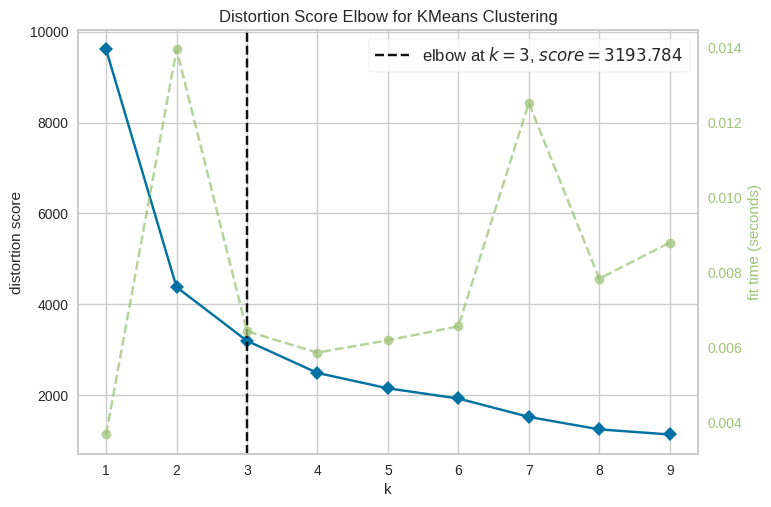

In [218]:
# PCA untuk mengurangi dimensi atau menghasilkan fitur baru
pca = PCA(n_components=3)  # Menghasilkan fitur baru dari data asli
X_pca = pca.fit_transform(df_rfm_minmax[['binRecency','binFrequency','binMonetary']])
visualizer = KElbowVisualizer(kmeans_elbow, k=(1, 10))
visualizer.fit(X_pca)
visualizer.show()
k_elbow=3
kmeans = KMeans(n_clusters=k_elbow)
kmeans.fit(X_pca)
labels = kmeans.labels_

# Catat label (cluster) setiap data
df_rfm['ClusterPCA'] = labels
df_rfm_minmax['ClusterPCA'] = labels



In [219]:
silhouette_score(X_pca, labels)

np.float64(0.33980147792116727)

In [220]:
visual_3d = go.Scatter3d(
    x= df_rfm_minmax['Recency'],
    y= df_rfm_minmax['Frequency'],
    z= df_rfm_minmax['Monetary'],
    mode='markers',
     marker=dict(
        color = df_rfm_minmax['ClusterPCA'],
        size= 20,
        line=dict(
            color= df_rfm_minmax['ClusterPCA'],
            width= 12
        ),
        opacity=0.8
     )
)
data = [visual_3d]
layout = go.Layout(
    title= 'Cluster_PP',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

In [ ]:
visual_3d = go.Scatter3d(
    x= df_rfm['Recency'],
    y= df_rfm['Frequency'],
    z= df_rfm['Monetary'],
    mode='markers',
     marker=dict(
        color = df_rfm['ClusterPCA'],
        size= 20,
        line=dict(
            color= df_rfm['ClusterPCA'],
            width= 12
        ),
        opacity=0.8
     )
)
data = [visual_3d]
layout = go.Layout(
    title= 'Cluster_PP',
    scene = dict(
            xaxis = dict(title  = 'Recency'),
            yaxis = dict(title  = 'Frequency'),
            zaxis = dict(title  = 'Monetary')
        )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

In [221]:
#coba pake dbscan
dbscan.fit(X_pca)
labels = dbscan.labels_

# Catat label (cluster) setiap data
df_rfm['Cluster_DBS_pca'] = labels
df_rfm_minmax['Cluster_DBS_pca'] = labels

In [222]:
# Analisis karakter cluster df_rfm
cluster_analysis_DBS = df_rfm.groupby('Cluster_DBS_pca').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Count=('CustomerID', 'count'),
    Percentage=('CustomerID', lambda x: (x.count() / len(df_rfm_minmax)) * 100)
).sort_values(by='Avg_Recency', ascending=False)

cluster_analysis_DBS

,Avg_Recency,Avg_Frequency,Avg_Monetary,Count,Percentage
Cluster_DBS_pca,,,,,
-1,372.000000,34.000000,4462.160000,1,0.023855
0,92.903288,3.668587,942.043361,4167,99.403626
1,3.583333,63.083333,15396.639167,24,0.572519


In [223]:
# Analisis karakter cluster df_rfm_minmax
cluster_analysis_DBS = df_rfm_minmax.groupby('Cluster_DBS_pca').agg(
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
).sort_values(by='Avg_Recency', ascending=False)

cluster_analysis_DBS

,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster_DBS_pca,,,
-1,0.998978,0.622878,0.740394
0,0.602707,0.132988,0.541640
1,0.124326,0.716328,0.818803


In [224]:
ss_dbs = silhouette_score(df_rfm, df_rfm['Cluster_DBS'])
print("Silhouette Score DBSCAN =", ss_dbs)

ss_dbs_minmax = silhouette_score(df_rfm_minmax, df_rfm['Cluster_DBS'])
print("Silhouette Score DBSCAN (MinMax) =", ss_dbs_minmax)

ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

In [225]:
visual_3d = go.Scatter3d(
  x= df_rfm_minmax['Recency'],
  y= df_rfm_minmax['Frequency'],
  z= df_rfm_minmax['Monetary'],
  mode='markers',
    marker=dict(
      color = df_rfm_minmax['Cluster_DBS_pca'],
      size= 20,
      line=dict(
        color= df_rfm_minmax['Cluster_DBS_pca'],
        width= 12
      ),
      opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
  title= 'Cluster_DBSCAN',
  scene = dict(
    xaxis = dict(title  = 'Recency'),
    yaxis = dict(title  = 'Frequency'),
    zaxis = dict(title  = 'Monetary')
  )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

In [ ]:
visual_3d = go.Scatter3d(
  x= df_rfm['Recency'],
  y= df_rfm['Frequency'],
  z= df_rfm['Monetary'],
  mode='markers',
    marker=dict(
      color = df_rfm['Cluster_DBS_pca'],
      size= 20,
      line=dict(
        color= df_rfm['Cluster_DBS_pca'],
        width= 12
      ),
      opacity=0.8
    )
)
data = [visual_3d]
layout = go.Layout(
  title= 'Cluster_DBSCAN',
  scene = dict(
    xaxis = dict(title  = 'Recency'),
    yaxis = dict(title  = 'Frequency'),
    zaxis = dict(title  = 'Monetary')
  )
)
fig = go.Figure(data=data, layout=layout)
fig.show(renderer="colab")

In [226]:
df_rfm_minmax.head(30)

,Recency,Frequency,Monetary,binRecency,binFrequency,binMonetary,Cluster,Cluster_DBS,ClusterPCA,Cluster_DBS_pca
0,0.077471,0.301688,0.714211,1,2,4,2,0,1,0
1,0.922529,0.150844,0.397619,5,1,2,1,0,0,0
2,0.439947,0.000000,0.608616,3,1,4,0,0,1,0
3,0.964245,0.000000,0.501166,5,1,3,1,0,2,0
4,0.557488,0.301688,0.619521,3,2,4,2,0,1,0
5,0.884612,0.000000,0.300537,5,1,2,1,0,0,0
6,0.909074,0.000000,0.575101,5,1,3,1,0,2,0
7,0.893712,0.000000,0.475201,5,1,3,1,0,2,0
8,0.920223,0.088238,0.615998,5,1,4,1,0,2,0
9,0.541332,0.000000,0.714229,3,1,4,0,0,1,0


In [ ]:
df_rfm.describe()